# FraudLens AI — Exploratory Data Analysis

Financial Fraud Detection & Transaction Intelligence Platform

## Dataset: PaySim Financial Transactions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


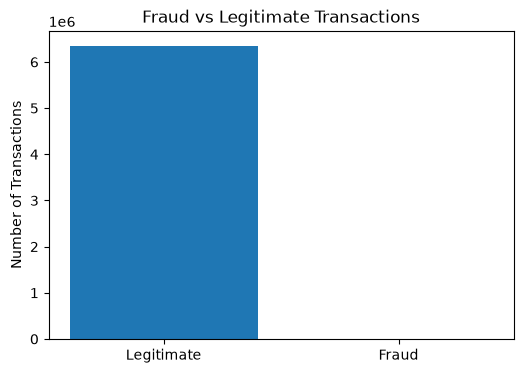

In [5]:
fraud_counts = df["isFraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], fraud_counts.values)
plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("Number of Transactions")
plt.show()

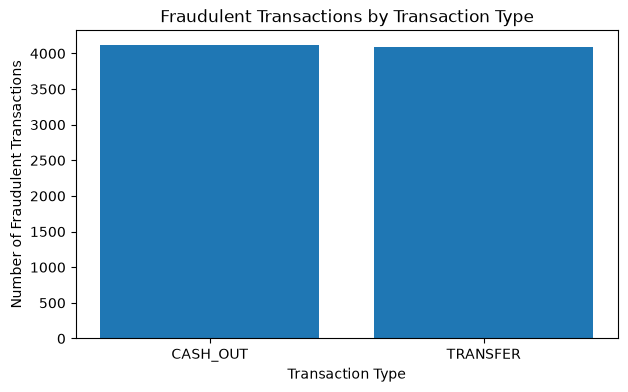

In [6]:
fraud_by_type = df[df["isFraud"] == 1]["type"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(fraud_by_type.index, fraud_by_type.values)
plt.title("Fraudulent Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

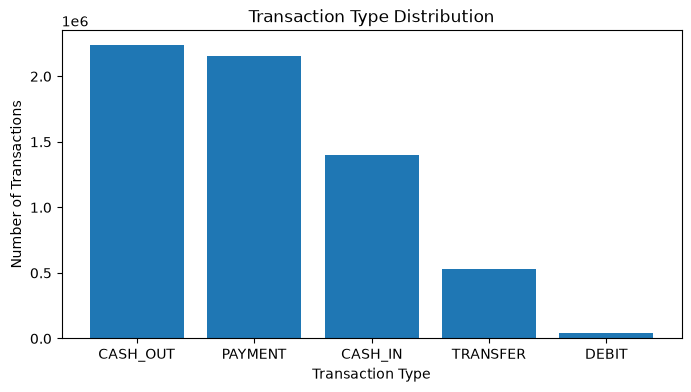

In [7]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [8]:
amount_comparison = df.groupby("isFraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_comparison

,count,mean,median,min,max
isFraud,,,,,
0,6354407,1.781970e+05,74684.72,0.01,92445516.64
1,8213,1.467967e+06,441423.44,0.00,10000000.00


In [9]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fraud_rate_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

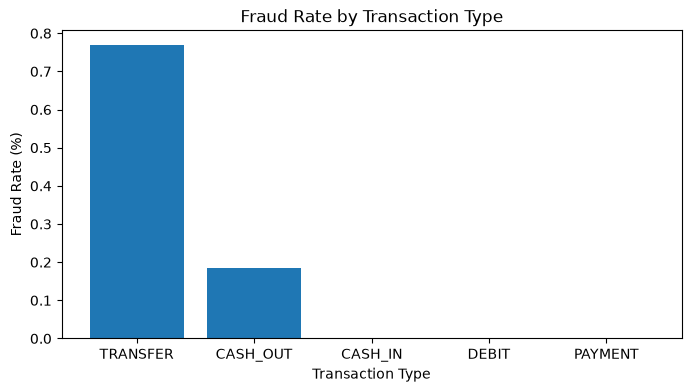

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(fraud_rate_by_type.index, fraud_rate_by_type.values)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

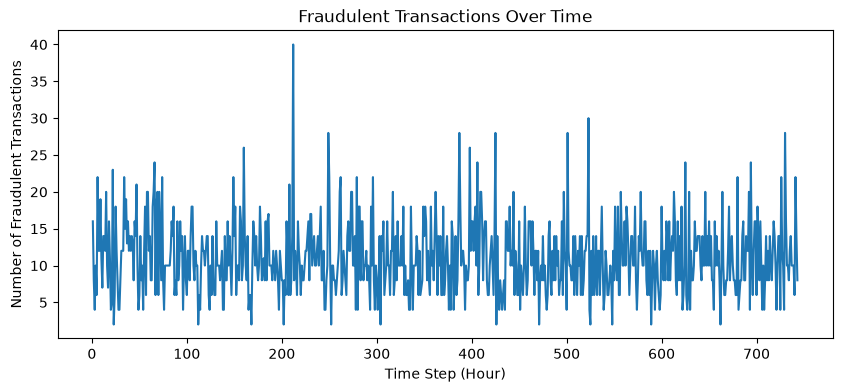

In [11]:
fraud_over_time = (
    df[df["isFraud"] == 1]
    .groupby("step")
    .size()
)

plt.figure(figsize=(10, 4))
plt.plot(fraud_over_time.index, fraud_over_time.values)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [12]:
df["day"] = ((df["step"] - 1) // 24) + 1
df["hour"] = (df["step"] - 1) % 24

df[["step", "day", "hour"]].head()

,step,day,hour
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0


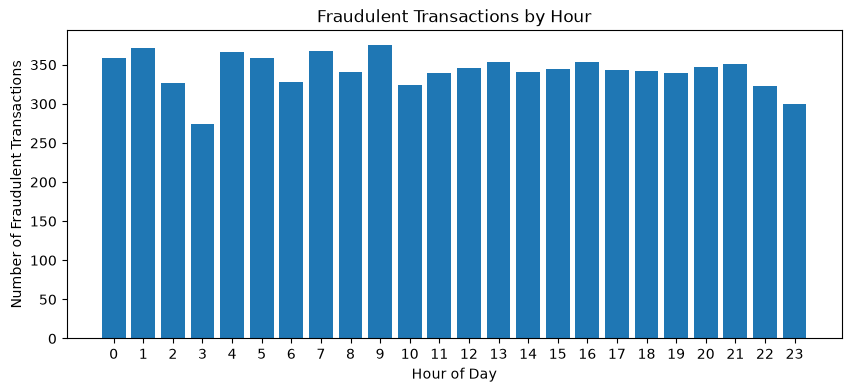

In [13]:
fraud_by_hour = (
    df[df["isFraud"] == 1]
    .groupby("hour")
    .size()
)

plt.figure(figsize=(10, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values)

plt.title("Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(24))

plt.show()

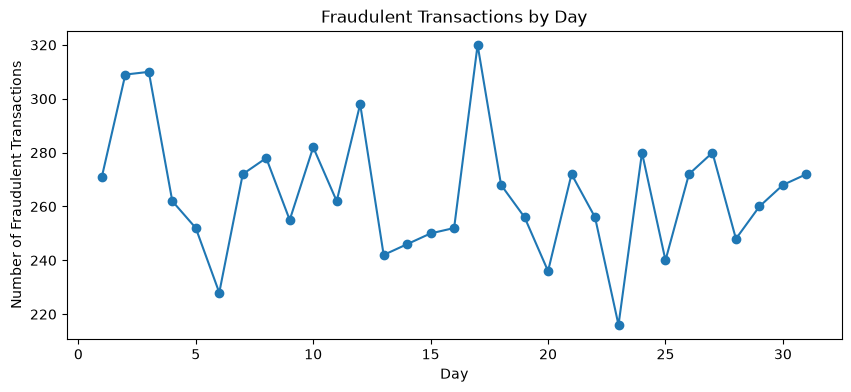

In [14]:
fraud_by_day = (
    df[df["isFraud"] == 1]
    .groupby("day")
    .size()
)

plt.figure(figsize=(10, 4))
plt.plot(fraud_by_day.index, fraud_by_day.values, marker="o")

plt.title("Fraudulent Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [15]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
)

df[[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "orig_balance_error",
    "dest_balance_error",
    "isFraud"
]].head()

,amount,oldbalanceOrg,newbalanceOrig,orig_balance_error,dest_balance_error,isFraud
0,9839.64,170136.0,160296.36,0.0,9839.64,0
1,1864.28,21249.0,19384.72,0.0,1864.28,0
2,181.00,181.0,0.00,0.0,181.00,1
3,181.00,181.0,0.00,0.0,21363.00,1
4,11668.14,41554.0,29885.86,0.0,11668.14,0


In [16]:
balance_error_comparison = df.groupby("isFraud")[
    ["orig_balance_error", "dest_balance_error"]
].mean()

balance_error_comparison

,orig_balance_error,dest_balance_error
isFraud,,
0,-201338.558109,54692.231734
1,-10692.325265,732509.301069
